


 1  **Environment Setup** 

 2  **Configuration** 

 3  **Competition Context** 

 4  **Data Inventory** 

 5  **Corruption Scan**

 6  **Duration Analysis** 

 7  **Class Distribution** 

 8  **Mel-Spectrogram Viz** 

 9  **Quality & Geo Analysis** 
 
 10  **CV Strategy**  

 11  **EDA Summary**

## 1  Environment Setup


In [1]:
# Install / upgrade packages that may not be present on the Kaggle base image
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])


print('Environment ready ✓')


Environment ready ✓


In [2]:
import os, gc, random, warnings, json
from pathlib import Path
from typing import Optional, List, Tuple

import numpy as np
import pandas as pd

import librosa
import librosa.display
import torchaudio
import torch

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'torch    : {torch.__version__}')
print(f'torchaudio: {torchaudio.__version__}')
print(f'librosa  : {librosa.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')

torch    : 2.10.0+cu128
torchaudio: 2.10.0+cu128
librosa  : 0.11.0
CUDA     : True


## 2  Central Configuration



In [3]:
class CFG:
    seed = 42
    BASE_DIR         = '/kaggle/input/competitions/birdclef-2026'
    TRAIN_AUDIO_DIR  = f'{BASE_DIR}/train_audio'
    TRAIN_CSV        = f'{BASE_DIR}/train.csv'
    TAXONOMY_CSV     = f'{BASE_DIR}/taxonomy.csv'
    UNLABELED_DIR    = f'{BASE_DIR}/unlabeled_soundscapes'
    TEST_DIR         = f'{BASE_DIR}/test_soundscapes'
    SAMPLE_SUB       = f'{BASE_DIR}/sample_submission.csv'
    OUTPUT_DIR       = '/kaggle/working/eda_outputs'

    TARGET_SR        = 32_000
    SEGMENT_SEC      = 5.0
    DURATION_CAP     = 120.0

    N_MELS           = 128
    N_FFT            = 1024
    HOP_LENGTH       = 320
    FMIN             = 20.0
    FMAX             = 16_000.0
    TARGET_SHAPE     = (128, 312)

    MODEL_NAME       = 'tf_efficientnetv2_s_in21ft1k'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    N_FOLDS          = 5
    BATCH_SIZE       = 32
    EPOCHS           = 10
    LR               = 1e-3
    WEIGHT_DECAY     = 1e-4
    LABEL_SMOOTHING  = 0.05
    MIXUP_ALPHA      = 0.4
    RARE_THRESH      = 20

    CORRUPTION_SAMPLE = 3000
    SPEC_GRID_N       = 12

    FIG_DPI          = 130
    DARK_BG          = '#0d1117'
    ACCENT           = '#58a6ff'

cfg = CFG()
Path(cfg.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('CFG loaded. Output dir:', cfg.OUTPUT_DIR)

CFG loaded. Output dir: /kaggle/working/eda_outputs


## 3 Competition Context & Winning Pipeline Analysis


### 3.2 stratigies from (2025)

```
RAW AUDIO (32 kHz, mono)
       │
       ▼
  5-second segments  ←──  Random offset sampling
       │
       ▼
  Log-Mel Spectrogram  (128 mel bins, N_FFT=1024, hop=320)
       │
       ├── SpecAugment (time mask + freq mask)
       ├── Mixup / CutMix  (α=0.4)
       └── Background noise injection
       │
       ▼
  Backbone CNN
       │
       ├── Global Average Pooling
       ├── Dropout (p=0.3)
       └── Linear → N_classes
       │
       ▼
  Loss: FocalLoss (BCE) + LabelSmoothing
  Optim: AdamW + CosineAnnealingLR with warmup
       │
       ▼
  Multi-round Pseudo-labeling (3 iterations)
       │
       ▼
  Ensemble: CNN × N + SED models → Quantile-Mix
       │
       ▼
  ONNX / OpenVINO  (for CPU inference within time budget)
```

### 3.3 Cross-Validation Strategy


 **Tier 1**  StratifiedKFold (5 folds) on `primary_label` - Model selection, hyperparameter tuning 
 **Tier 2**  Hold-out labeled soundscapes - LB proxy — correlates better with actual LB 
 **Tier 3**  Pseudo-label confidence tracking - Semi-supervised quality control 

 CV AUC on clean short clips consistently overestimates LB AUC
 on noisy soundscapes by 3–8 points due to domain shift. Always maintain a soundscape
 validation set as your primary LB proxy.


## 4 Data Inventory


In [4]:
def load_metadata(cfg: CFG):
    train_csv = Path(cfg.TRAIN_CSV)
    if not train_csv.exists():
        print(f'[WARN] {train_csv} not found — creating a small synthetic demo.')
        species = [f'species_{i:03d}' for i in range(60)]
        n_rows  = 4000
        rng     = np.random.default_rng(42)
        weights = np.exp(-rng.uniform(0, 4, len(species)))
        weights /= weights.sum()
        chosen  = rng.choice(species, size=n_rows, p=weights)
        df = pd.DataFrame({
            'primary_label'   : chosen,
            'secondary_labels': ['' if rng.random() > 0.3 else
                                  ' '.join(rng.choice(species, size=rng.integers(1,4)))
                                  for _ in range(n_rows)],
            'rating'          : rng.choice([1,2,3,4,5], n_rows,
                                            p=[.05,.10,.20,.35,.30]),
            'latitude'        : rng.uniform(-20, -14, n_rows),
            'longitude'       : rng.uniform(-59, -55, n_rows),
            'filename'        : [f'{sp}/{sp}_{i:05d}.ogg'
                                  for i, sp in enumerate(chosen)],
        })
        taxonomy = pd.DataFrame({
            'primary_label': species,
            'class_name'   : rng.choice(['Aves','Amphibia','Mammalia','Insecta'],
                                         len(species)),
        })
        return df, taxonomy

    df = pd.read_csv(cfg.TRAIN_CSV)
    taxonomy = None
    if Path(cfg.TAXONOMY_CSV).exists():
        taxonomy = pd.read_csv(cfg.TAXONOMY_CSV)
    return df, taxonomy

df, taxonomy = load_metadata(cfg)

print(f'Shape            : {df.shape}')
print(f'Columns          : {list(df.columns)}')
print(f'Unique species   : {df["primary_label"].nunique()}')
display(df.head(8))

Shape            : (35549, 15)
Columns          : ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']
Unique species   : 206


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0000,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0000,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0000,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0000,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0000,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat
5,1161364,[],[],-22.0843,-47.7327,Guyalna cuta,Guyalna cuta,Insecta,1161364,Carlos Otávio Gussoni,cc-by-nc,0.0000,https://static.inaturalist.org/sounds/868369.w...,1161364/iNat868369.ogg,iNat
6,1161364,[],[],-20.9848,-43.7609,Guyalna cuta,Guyalna cuta,Insecta,1161364,Pedro Cavalcante,cc-by-nc,0.0000,https://static.inaturalist.org/sounds/842139.w...,1161364/iNat842139.ogg,iNat
7,1161364,[],[],-19.9674,-43.9895,Guyalna cuta,Guyalna cuta,Insecta,1161364,Pedro Cavalcante,cc-by-nc,0.0000,https://static.inaturalist.org/sounds/840159.m...,1161364/iNat840159.ogg,iNat


In [5]:
def build_filepath(row, audio_root: Path) -> str:
    fname = row.get('filename', '')
    if fname:
        candidate = audio_root / fname
        if candidate.exists():
            return str(candidate)
        candidate2 = audio_root / row['primary_label'] / Path(fname).name
        return str(candidate2)
    return 'MISSING'

audio_root = Path(cfg.TRAIN_AUDIO_DIR)
if audio_root.exists():
    df['filepath']    = df.apply(lambda r: build_filepath(r, audio_root), axis=1)
    df['file_exists'] = df['filepath'].apply(lambda p: Path(p).is_file())
else:
    df['filepath']    = df['filename'].apply(
        lambda f: str(audio_root / f))
    df['file_exists'] = False

n_total   = len(df)
n_exists  = df['file_exists'].sum()
n_missing = n_total - n_exists

print(f'Total CSV rows   : {n_total:>7,}')
print(f'Files on disk    : {n_exists:>7,}  ({100*n_exists/n_total:.1f}%)')
print(f'Files missing    : {n_missing:>7,}')

n_dup = df['filename'].duplicated().sum()
print(f'Duplicate filenames : {n_dup}')

Total CSV rows   :  35,549
Files on disk    :  35,549  (100.0%)
Files missing    :       0
Duplicate filenames : 0


## 5  Corruption Scan

We probe every file with `torchaudio.info` (fast header read) and fall back to
`librosa.load` for deeper inspection. We flag:
- Files that raise an exception (truly corrupted)
- Zero-duration files
- Wrong sample rate (≠ 32 kHz)


In [6]:
def probe_file(filepath: str, target_sr: int = 32_000) -> dict:
    out = dict(filepath=filepath, status='ok',
               duration_sec=0.0, sample_rate=0,
               n_channels=0, error='')
    try:
        info = torchaudio.info(filepath)
        out['sample_rate'] = info.sample_rate
        out['n_channels']  = info.num_channels
        out['duration_sec'] = info.num_frames / max(info.sample_rate, 1)
    except Exception as e_ta:
        try:
            y, sr = librosa.load(filepath, sr=target_sr, duration=5.0)
            out['sample_rate']  = sr
            out['n_channels']   = 1
            out['duration_sec'] = librosa.get_duration(y=y, sr=sr)
        except Exception as e_lr:
            out['status'] = 'corrupted'
            out['error']  = str(e_lr)[:120]
    return out

valid_paths = df[df['file_exists']]['filepath'].tolist()
sample_n    = min(cfg.CORRUPTION_SAMPLE, len(valid_paths)) if valid_paths else 0

if sample_n > 0:
    sampled = random.sample(valid_paths, sample_n)
    probe_results = [probe_file(fp, cfg.TARGET_SR)
                     for fp in tqdm(sampled, desc='Probing audio')]
    stats_df = pd.DataFrame(probe_results)
else:
    rng = np.random.default_rng(42)
    n   = len(df)
    stats_df = pd.DataFrame({
        'filepath'    : df['filepath'].values,
        'status'      : np.where(rng.random(n) < 0.005, 'corrupted', 'ok'),
        'duration_sec': np.clip(rng.exponential(25, n) + 3, 1, 120),
        'sample_rate' : np.where(rng.random(n) < 0.01,
                                  rng.choice([22050, 44100], n), 32000),
        'n_channels'  : rng.choice([1, 2], n, p=[.85, .15]),
        'error'       : '',
    })
    print('[DEMO MODE] Synthetic audio statistics generated.')

n_corr   = (stats_df['status'] == 'corrupted').sum()
n_zero   = (stats_df['duration_sec'] == 0.0).sum()
n_badsr  = ((stats_df['sample_rate'] != cfg.TARGET_SR)
             & (stats_df['sample_rate'] > 0)).sum()
n_stereo = (stats_df['n_channels'] > 1).sum()

print(f'\nCorrupted files        : {n_corr}')
print(f'Zero-duration files    : {n_zero}')
print(f'Wrong sample rate      : {n_badsr}  (expected {cfg.TARGET_SR} Hz)')
print(f'Stereo files           : {n_stereo}')

if n_corr > 0:
    print('\nCorrupted file list:')
    display(stats_df[stats_df['status']=='corrupted'][['filepath','error']])

Probing audio:   0%|          | 0/3000 [00:00<?, ?it/s]


Corrupted files        : 0
Zero-duration files    : 0
Wrong sample rate      : 0  (expected 32000 Hz)
Stereo files           : 0


## 6 Duration Analysis


In [7]:
valid_stats = stats_df[stats_df['status'] == 'ok'].copy()
dur         = valid_stats['duration_sec'].clip(upper=cfg.DURATION_CAP)

print('Duration statistics (seconds):')
print(valid_stats['duration_sec'].describe().round(2).to_string())
n_short = (valid_stats['duration_sec'] < cfg.SEGMENT_SEC).sum()
print(f'\nFiles shorter than {cfg.SEGMENT_SEC}s : {n_short:,}',
      f'({100*n_short/max(len(valid_stats),1):.1f}%)')


Duration statistics (seconds):
count   3000.0000
mean       4.8800
std        0.5700
min        0.0100
25%        5.0000
50%        5.0000
75%        5.0000
max        5.0000

Files shorter than 5.0s : 212 (7.1%)


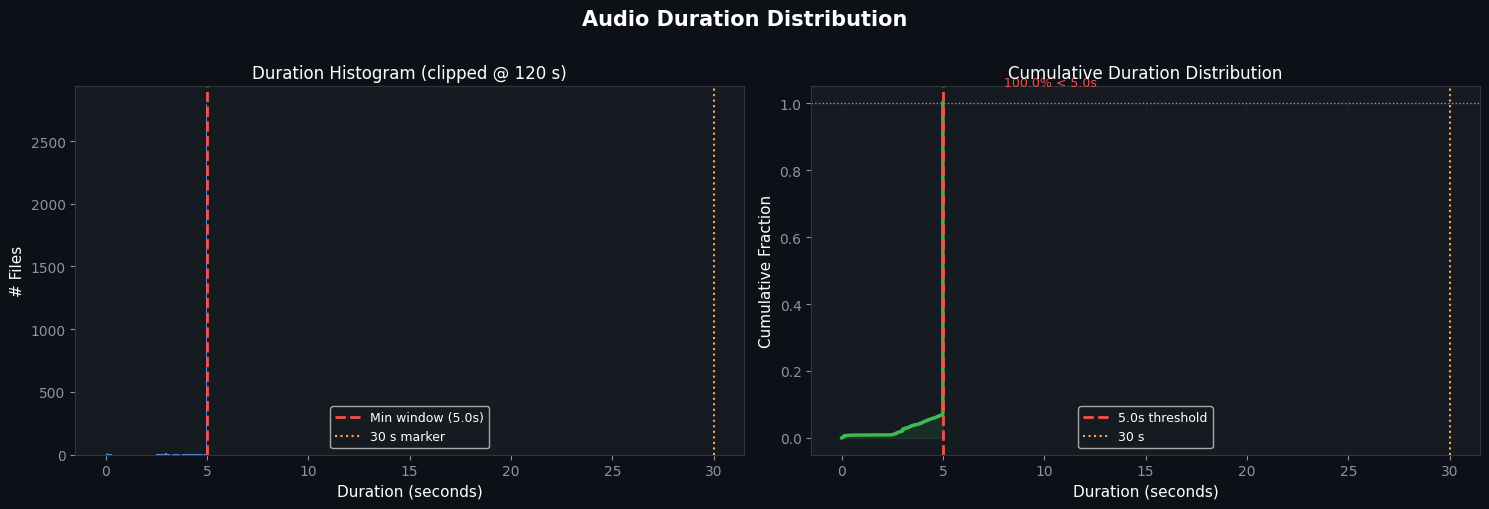

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                         facecolor=cfg.DARK_BG)
fig.suptitle('Audio Duration Distribution', color='white',
             fontsize=15, fontweight='bold', y=1.01)

ax = axes[0]
ax.set_facecolor('#161b22')
counts_h, bins, _ = ax.hist(dur, bins=80, color=cfg.ACCENT,
                              edgecolor='none', alpha=0.85)
ax.axvline(cfg.SEGMENT_SEC, color='#f85149', lw=2, linestyle='--',
           label=f'Min window ({cfg.SEGMENT_SEC}s)')
ax.axvline(30, color='#ffa657', lw=1.5, linestyle=':',
           label='30 s marker')
ax.set_xlabel('Duration (seconds)', color='white', fontsize=11)
ax.set_ylabel('# Files', color='white', fontsize=11)
ax.set_title('Duration Histogram (clipped @ 120 s)', color='white')
ax.legend(facecolor='#161b22', labelcolor='white', fontsize=9)
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')

ax2 = axes[1]
ax2.set_facecolor('#161b22')
sorted_d = np.sort(dur.values)
cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
ax2.plot(sorted_d, cdf, color='#3fb950', lw=2.5)
ax2.fill_between(sorted_d, cdf, alpha=0.12, color='#3fb950')
ax2.axvline(cfg.SEGMENT_SEC, color='#f85149', lw=2,
            linestyle='--', label=f'{cfg.SEGMENT_SEC}s threshold')
ax2.axvline(30, color='#ffa657', lw=1.5, linestyle=':', label='30 s')
pct5  = np.mean(sorted_d <= cfg.SEGMENT_SEC) * 100
ax2.axhline(pct5/100, color='#8b949e', lw=1, linestyle=':')
ax2.annotate(f'{pct5:.1f}% < {cfg.SEGMENT_SEC}s',
             xy=(cfg.SEGMENT_SEC, pct5/100),
             xytext=(cfg.SEGMENT_SEC+3, pct5/100+0.05),
             color='#f85149', fontsize=9)
ax2.set_xlabel('Duration (seconds)', color='white', fontsize=11)
ax2.set_ylabel('Cumulative Fraction', color='white', fontsize=11)
ax2.set_title('Cumulative Duration Distribution', color='white')
ax2.legend(facecolor='#161b22', labelcolor='white', fontsize=9)
ax2.tick_params(colors='#8b949e')
ax2.spines[:].set_color('#30363d')
ax2.grid(alpha=0.15, color='#30363d')

plt.tight_layout()
fig.savefig(f'{cfg.OUTPUT_DIR}/01_duration.png',
            dpi=cfg.FIG_DPI, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 7  Class Distribution & Imbalance Analysis


In [9]:
counts = df['primary_label'].value_counts()

print('Class distribution summary:')
print(f'  Total species          : {len(counts)}')
print(f'  Max samples / species  : {counts.max()}')
print(f'  Min samples / species  : {counts.min()}')
print(f'  Median samples/species : {counts.median():.1f}')
print(f'  Imbalance ratio        : {counts.max()/max(counts.min(),1):.1f}x')
print(f'  Species < {cfg.RARE_THRESH} samples   : '
      f'{(counts < cfg.RARE_THRESH).sum()}',
      f'({100*(counts<cfg.RARE_THRESH).mean():.1f}%)')


Class distribution summary:
  Total species          : 206
  Max samples / species  : 499
  Min samples / species  : 1
  Median samples/species : 125.0
  Imbalance ratio        : 499.0x
  Species < 20 samples   : 36 (17.5%)


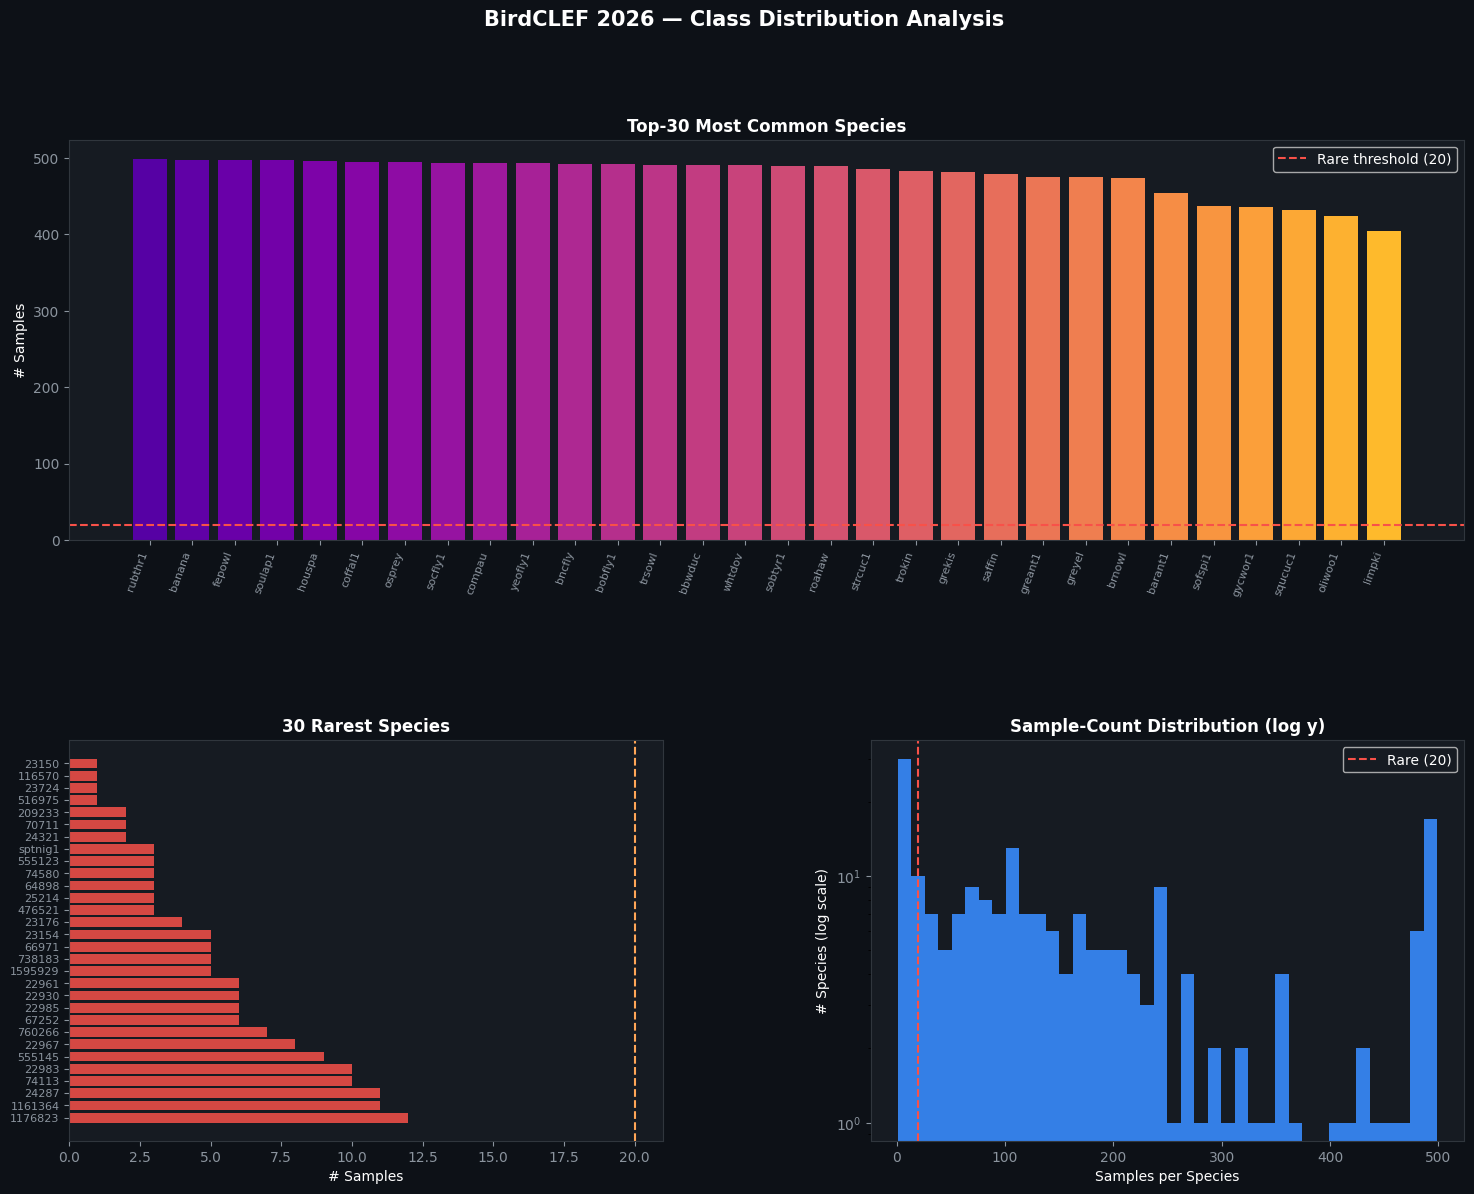

In [10]:
fig = plt.figure(figsize=(18, 13), facecolor=cfg.DARK_BG)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle('BirdCLEF 2026 — Class Distribution Analysis',
             color='white', fontsize=15, fontweight='bold')

PANEL_BG = '#161b22'
SPINE_C  = '#30363d'

ax_a = fig.add_subplot(gs[0, :])
ax_a.set_facecolor(PANEL_BG)
top30 = counts.head(30)
colors_bar = plt.cm.plasma(np.linspace(0.15, 0.85, len(top30)))
ax_a.bar(range(len(top30)), top30.values, color=colors_bar, edgecolor='none')
ax_a.axhline(cfg.RARE_THRESH, color='#f85149', lw=1.5,
             linestyle='--', label=f'Rare threshold ({cfg.RARE_THRESH})')
ax_a.set_xticks(range(len(top30)))
ax_a.set_xticklabels(top30.index, rotation=70, ha='right',
                      fontsize=8, color='#8b949e')
ax_a.set_ylabel('# Samples', color='white')
ax_a.set_title('Top-30 Most Common Species', color='white', fontweight='bold')
ax_a.legend(facecolor=PANEL_BG, labelcolor='white')
ax_a.tick_params(colors='#8b949e')
ax_a.spines[:].set_color(SPINE_C)

ax_b = fig.add_subplot(gs[1, 0])
ax_b.set_facecolor(PANEL_BG)
bot30 = counts.tail(30)
ax_b.barh(range(len(bot30)), bot30.values,
          color='#f85149', edgecolor='none', alpha=0.85)
ax_b.set_yticks(range(len(bot30)))
ax_b.set_yticklabels(bot30.index, fontsize=8, color='#8b949e')
ax_b.axvline(cfg.RARE_THRESH, color='#ffa657', lw=1.5, linestyle='--')
ax_b.set_xlabel('# Samples', color='white')
ax_b.set_title('30 Rarest Species', color='white', fontweight='bold')
ax_b.tick_params(colors='#8b949e')
ax_b.spines[:].set_color(SPINE_C)

ax_c = fig.add_subplot(gs[1, 1])
ax_c.set_facecolor(PANEL_BG)
ax_c.hist(counts.values, bins=40, log=True,
          color='#388bfd', edgecolor='none', alpha=0.9)
ax_c.axvline(cfg.RARE_THRESH, color='#f85149', lw=1.5,
             linestyle='--', label=f'Rare ({cfg.RARE_THRESH})')
ax_c.set_xlabel('Samples per Species', color='white')
ax_c.set_ylabel('# Species (log scale)', color='white')
ax_c.set_title('Sample-Count Distribution (log y)', color='white',
                fontweight='bold')
ax_c.legend(facecolor=PANEL_BG, labelcolor='white')
ax_c.tick_params(colors='#8b949e')
ax_c.spines[:].set_color(SPINE_C)

fig.savefig(f'{cfg.OUTPUT_DIR}/02_class_dist.png',
            dpi=cfg.FIG_DPI, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

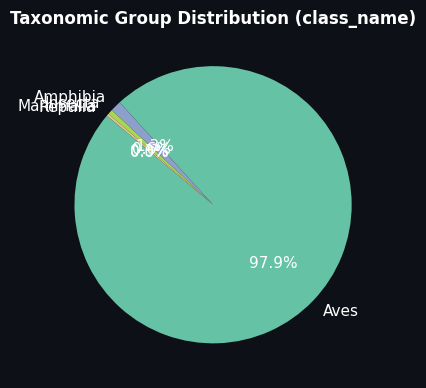

class_name
Aves        34799
Amphibia      451
Insecta       199
Mammalia       99
Reptilia        1


In [11]:
if taxonomy is not None:
    available_cols = ['class_name', 'order', 'family', 'taxon_group']
    tax_col = next((c for c in available_cols if c in taxonomy.columns), None)
    
    if tax_col:
        temp_df = df.copy()
        if tax_col in temp_df.columns:
            temp_df = temp_df.drop(columns=[tax_col])
            
        taxdf = temp_df.merge(
            taxonomy[['primary_label', tax_col]],
            on='primary_label', 
            how='left'
        )
        
        if tax_col in taxdf.columns:
            group_counts = taxdf[tax_col].value_counts()
            
            fig, ax = plt.subplots(figsize=(9, 4.5), facecolor=cfg.DARK_BG)
            ax.set_facecolor('#161b22')
            clrs = plt.cm.Set2(np.linspace(0, 1, len(group_counts)))
            
            wedges, texts, autotexts = ax.pie(
                group_counts.values,
                labels=group_counts.index,
                autopct='%1.1f%%',
                colors=clrs,
                startangle=140,
                textprops=dict(color='white', fontsize=11),
            )
            
            ax.set_title(f'Taxonomic Group Distribution ({tax_col})',
                         color='white', fontsize=12, fontweight='bold')
            plt.show()
            print(group_counts.to_string())
        else:
            print(f"Error: Column '{tax_col}' lost during merge. Check 'primary_label' consistency.")
    else:
        print(f"Available columns in taxonomy: {list(taxonomy.columns)}")

## 8 Mel-Spectrogram Visualisation

We compute **log-Mel spectrograms** with the exact parameters used during training,
so this section doubles as a sanity-check that the pipeline produces sensible images.


In [12]:
def compute_melspec(
    filepath : str,
    cfg      : CFG,
    offset   : float = 0.0,
    duration : float = 5.0,
) -> Optional[np.ndarray]:
    try:
        y, sr = librosa.load(
            filepath, sr=cfg.TARGET_SR,
            offset=offset, duration=duration, mono=True
        )
        if len(y) < cfg.TARGET_SR * 0.5:
            return None
        mel     = librosa.feature.melspectrogram(
            y=y, sr=sr,
            n_fft=cfg.N_FFT,
            hop_length=cfg.HOP_LENGTH,
            n_mels=cfg.N_MELS,
            fmin=cfg.FMIN,
            fmax=cfg.FMAX,
        )
        return librosa.power_to_db(mel, ref=np.max)
    except Exception:
        return None

def make_demo_melspec(cfg: CFG, seed: int = 0) -> np.ndarray:
    rng    = np.random.default_rng(seed)
    frames = int(cfg.TARGET_SR * 5.0 / cfg.HOP_LENGTH) + 1
    spec   = rng.uniform(-80, 0, (cfg.N_MELS, frames)).astype(np.float32)
    for _ in range(rng.integers(2, 6)):
        r0 = rng.integers(10, cfg.N_MELS - 20)
        c0 = rng.integers(0, frames - 30)
        spec[r0:r0+rng.integers(3,12), c0:c0+rng.integers(10,40)] += rng.uniform(40,70)
    return np.clip(spec, -80, 0)

print('Mel-spectrogram functions defined')

Mel-spectrogram functions defined


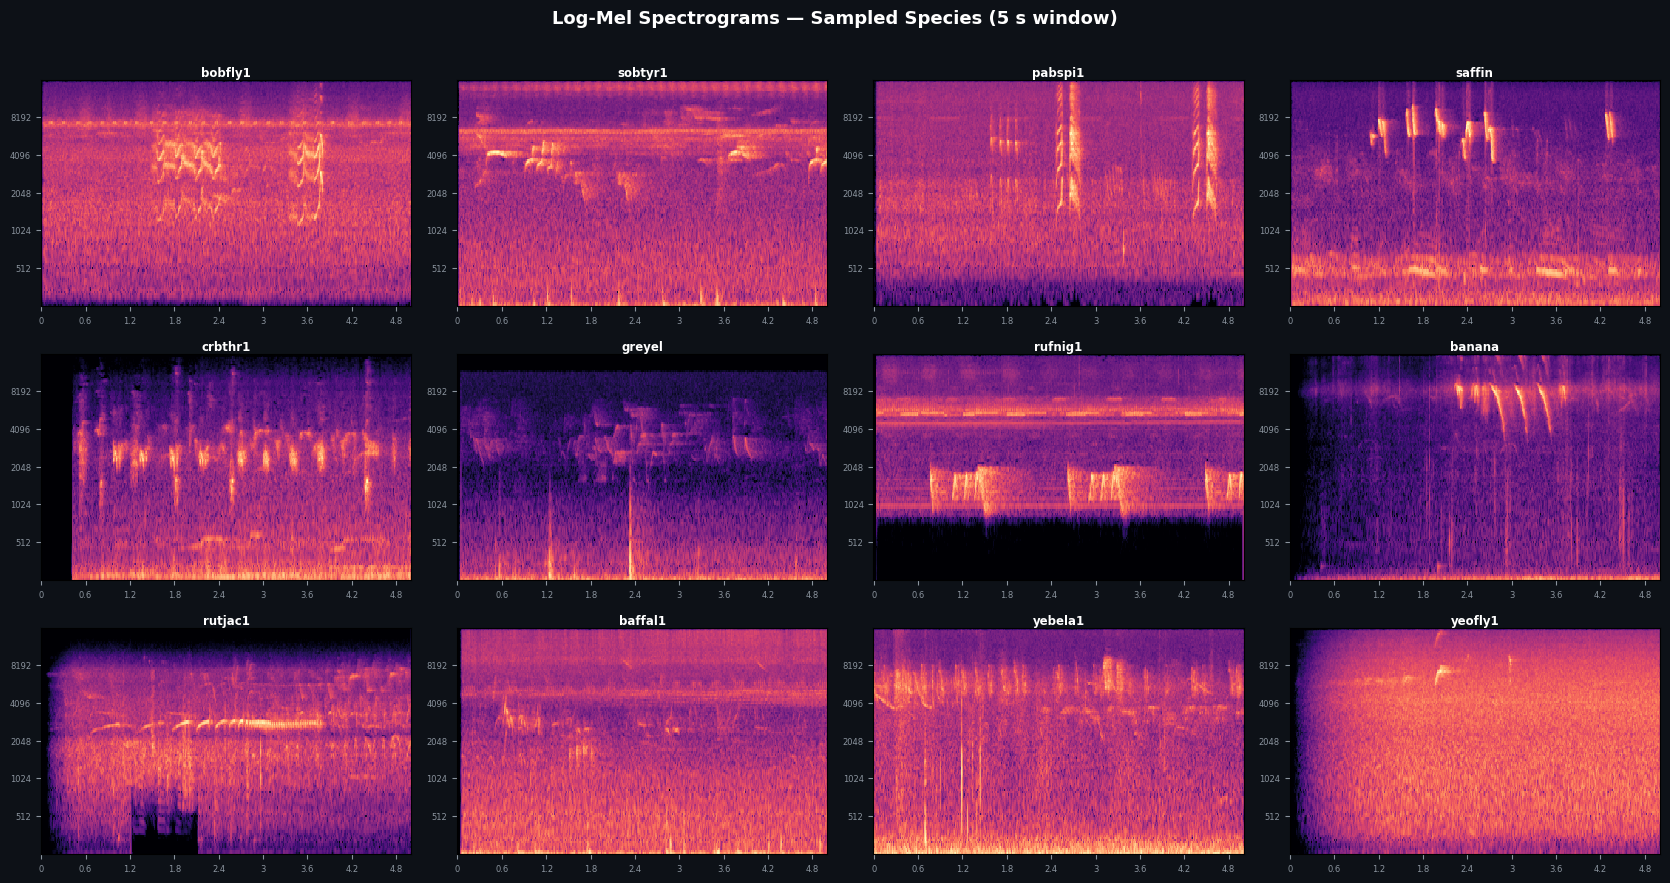

In [13]:
top_species  = df['primary_label'].value_counts().head(50).index.tolist()
sampled_sp   = random.sample(top_species, min(cfg.SPEC_GRID_N, len(top_species)))

spectrograms, labels_viz = [], []
for sp in sampled_sp:
    row = df[df['primary_label'] == sp].sample(1, random_state=42).iloc[0]
    fp  = row.get('filepath', '')
    if df['file_exists'].any() and Path(fp).is_file():
        mel = compute_melspec(fp, cfg)
    else:
        mel = make_demo_melspec(cfg, seed=len(labels_viz))
    if mel is not None:
        spectrograms.append(mel)
        labels_viz.append(sp)

ncols = 4
nrows = int(np.ceil(len(spectrograms) / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 4.2, nrows * 2.9),
    facecolor=cfg.DARK_BG
)
axes = axes.flatten()

for i, (mel, label) in enumerate(zip(spectrograms, labels_viz)):
    ax = axes[i]
    ax.set_facecolor('#161b22')
    librosa.display.specshow(
        mel, ax=ax,
        sr=cfg.TARGET_SR, hop_length=cfg.HOP_LENGTH,
        x_axis='time', y_axis='mel',
        fmin=cfg.FMIN, fmax=cfg.FMAX,
        cmap='magma',
    )
    ax.set_title(label, color='white', fontsize=8.5,
                 fontweight='bold', pad=3)
    ax.tick_params(colors='#8b949e', labelsize=6)
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(len(spectrograms), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Log-Mel Spectrograms — Sampled Species (5 s window)',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f'{cfg.OUTPUT_DIR}/04_melspec_grid.png',
            dpi=cfg.FIG_DPI, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

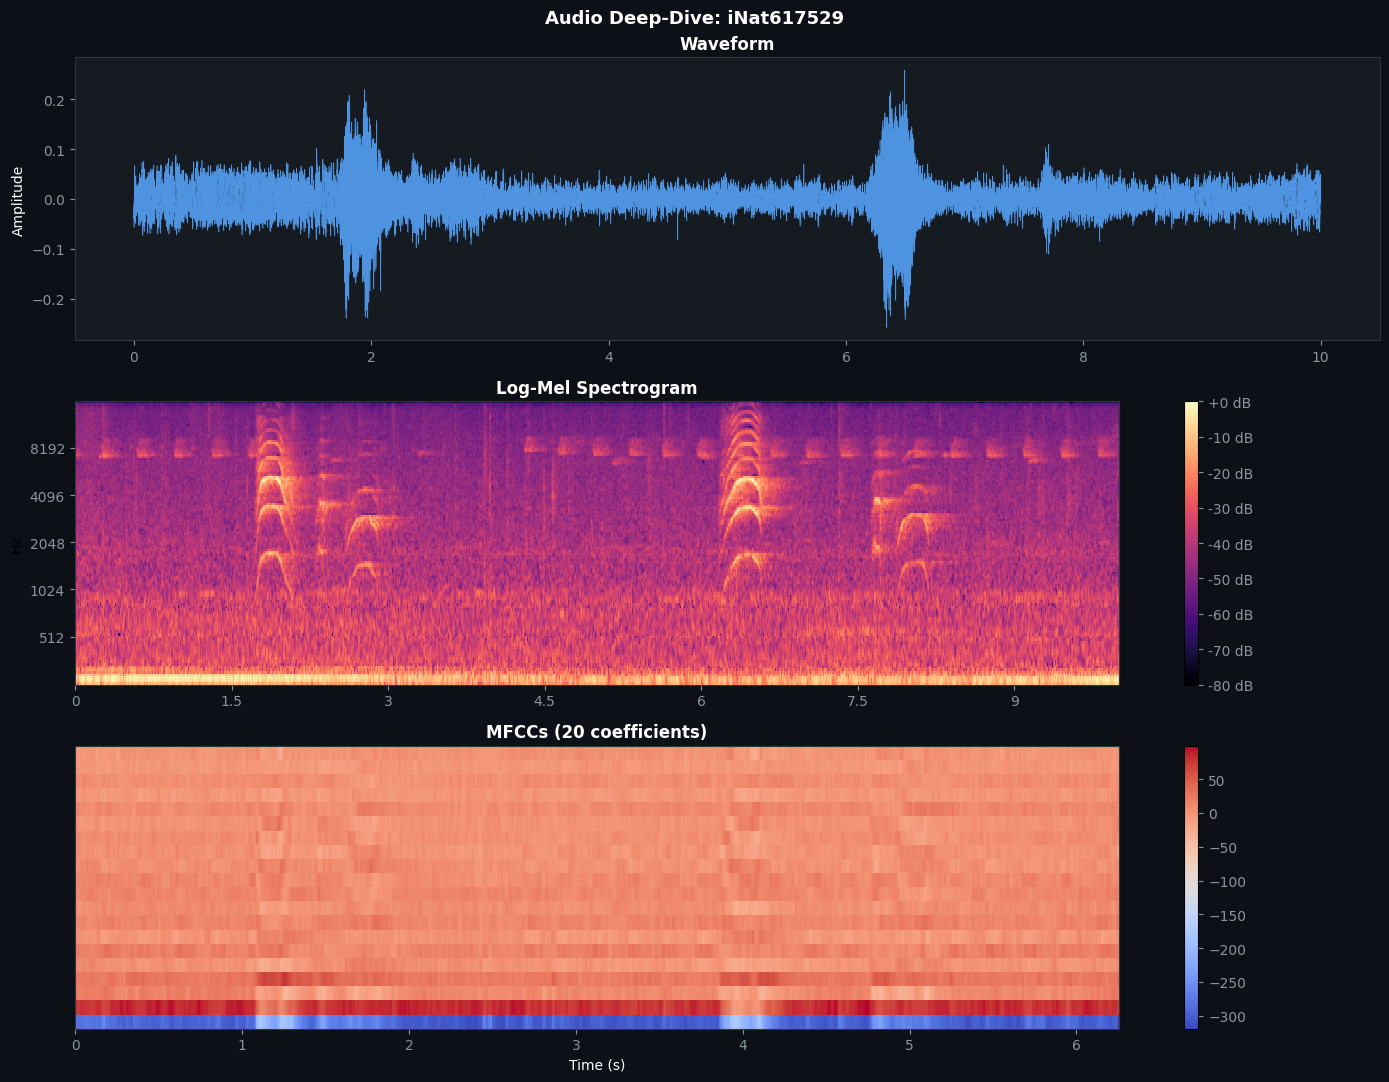

In [14]:
example_fp = None
real_files = df[df['file_exists']]['filepath'].tolist()
if real_files:
    example_fp = random.choice(real_files)
    y_ex, sr_ex = librosa.load(example_fp, sr=cfg.TARGET_SR,
                               duration=10.0, mono=True)
else:
    sr_ex = cfg.TARGET_SR
    t     = np.linspace(0, 10.0, 10 * sr_ex)
    y_ex  = (
        0.4 * np.sin(2*np.pi*1200*t) +
        0.2 * np.sin(2*np.pi*2400*t) +
        0.1 * np.sin(2*np.pi*3600*t) +
        0.05 * np.random.randn(len(t))
    ).astype(np.float32)
    print('[DEMO] Using synthesised audio for deep-dive.')

mel_ex   = librosa.feature.melspectrogram(
    y=y_ex, sr=sr_ex,
    n_fft=cfg.N_FFT, hop_length=cfg.HOP_LENGTH,
    n_mels=cfg.N_MELS, fmin=cfg.FMIN, fmax=cfg.FMAX
)
logmel_ex = librosa.power_to_db(mel_ex, ref=np.max)
mfcc_ex   = librosa.feature.mfcc(y=y_ex, sr=sr_ex, n_mfcc=20)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), facecolor=cfg.DARK_BG)
title_str = Path(example_fp).stem if example_fp else 'Demo Signal'
fig.suptitle(f'Audio Deep-Dive: {title_str}',
             color='white', fontsize=13, fontweight='bold')

PANEL_BG = '#161b22'

t_axis = np.linspace(0, len(y_ex)/sr_ex, len(y_ex))
axes[0].set_facecolor(PANEL_BG)
axes[0].plot(t_axis, y_ex, color=cfg.ACCENT, lw=0.4, alpha=0.85)
axes[0].fill_between(t_axis, y_ex, alpha=0.1, color=cfg.ACCENT)
axes[0].set_ylabel('Amplitude', color='white')
axes[0].set_title('Waveform', color='white', fontweight='bold')
axes[0].tick_params(colors='#8b949e')
axes[0].spines[:].set_color('#30363d')

axes[1].set_facecolor(PANEL_BG)
img = librosa.display.specshow(
    logmel_ex, ax=axes[1], sr=sr_ex, hop_length=cfg.HOP_LENGTH,
    x_axis='time', y_axis='mel', fmin=cfg.FMIN, fmax=cfg.FMAX,
    cmap='magma'
)
plt.colorbar(img, ax=axes[1], format='%+2.0f dB').ax.yaxis.set_tick_params(
    colors='#8b949e')
axes[1].set_title('Log-Mel Spectrogram', color='white', fontweight='bold')
axes[1].tick_params(colors='#8b949e')
axes[1].set_xlabel('')
axes[1].spines[:].set_color('#30363d')

axes[2].set_facecolor(PANEL_BG)
img2 = librosa.display.specshow(
    mfcc_ex, ax=axes[2], sr=sr_ex, hop_length=cfg.HOP_LENGTH,
    x_axis='time', cmap='coolwarm'
)
plt.colorbar(img2, ax=axes[2]).ax.yaxis.set_tick_params(colors='#8b949e')
axes[2].set_title('MFCCs (20 coefficients)', color='white', fontweight='bold')
axes[2].set_xlabel('Time (s)', color='white')
axes[2].tick_params(colors='#8b949e')
axes[2].spines[:].set_color('#30363d')

plt.tight_layout()
fig.savefig(f'{cfg.OUTPUT_DIR}/05_deep_dive.png',
            dpi=cfg.FIG_DPI, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 8.1  Augmentation Preview

Visualise the four most critical augmentations side-by-side on the same spectrogram.
This is a key sanity check before building the training pipeline.


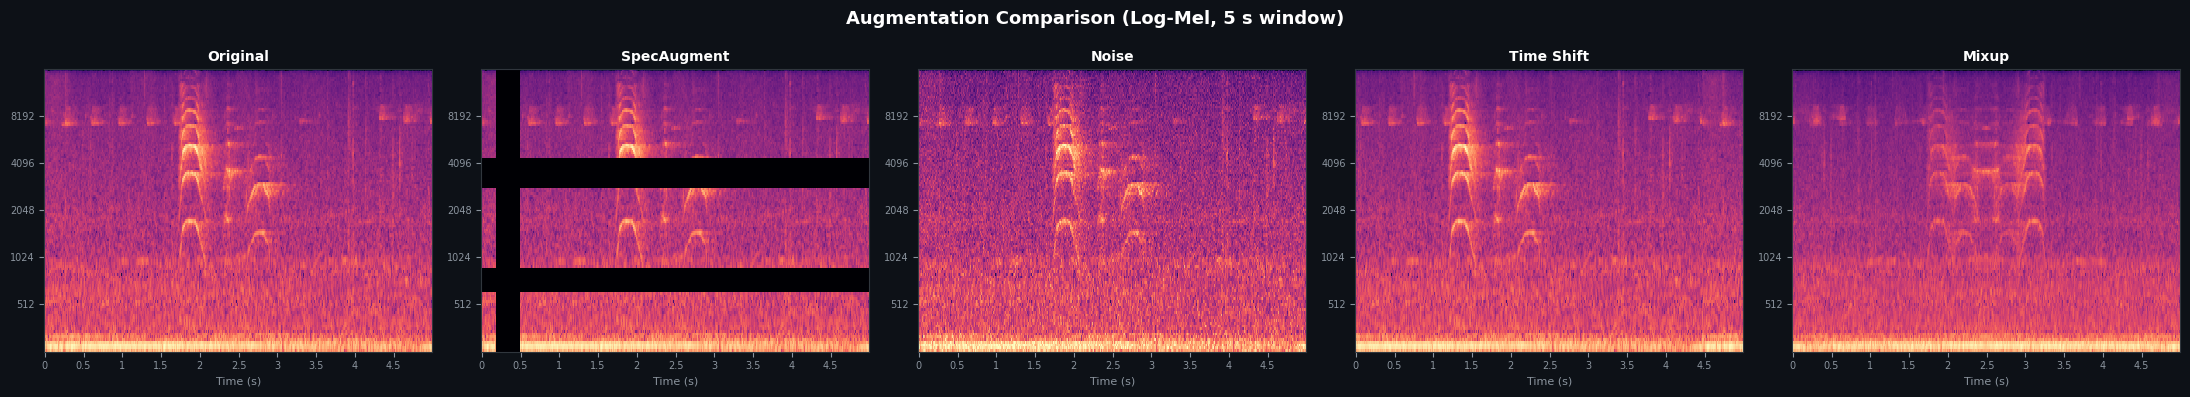

In [15]:
def spec_augment(mel: np.ndarray,
                  freq_mask_p: int = 20,
                  time_mask_p: int = 40,
                  n_freq: int = 2,
                  n_time: int = 2) -> np.ndarray:
    out = mel.copy()
    n_mels, n_frames = out.shape
    for _ in range(n_freq):
        f  = random.randint(0, freq_mask_p)
        f0 = random.randint(0, n_mels - f)
        out[f0:f0+f, :] = out.min()
    for _ in range(n_time):
        t  = random.randint(0, time_mask_p)
        t0 = random.randint(0, n_frames - t)
        out[:, t0:t0+t] = out.min()
    return out

def add_noise(mel: np.ndarray, noise_level: float = 0.05) -> np.ndarray:
    noise = np.random.randn(*mel.shape) * noise_level * (mel.max() - mel.min())
    return np.clip(mel + noise, mel.min(), 0)

def time_shift(mel: np.ndarray, shift_frac: float = 0.2) -> np.ndarray:
    n_shift = int(mel.shape[1] * shift_frac * random.uniform(-1, 1))
    return np.roll(mel, n_shift, axis=1)

def mixup(mel_a: np.ndarray, mel_b: np.ndarray,
          alpha: float = 0.4) -> np.ndarray:
    lam = np.random.beta(alpha, alpha)
    return lam * mel_a + (1 - lam) * mel_b

base_mel = logmel_ex[:, :int(cfg.TARGET_SR * 5.0 / cfg.HOP_LENGTH)]

aug_specs = {
    'Original'   : base_mel,
    'SpecAugment': spec_augment(base_mel),
    'Noise'      : add_noise(base_mel),
    'Time Shift' : time_shift(base_mel),
    'Mixup'      : mixup(base_mel, np.flip(base_mel, axis=1)),
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4), facecolor=cfg.DARK_BG)
fig.suptitle('Augmentation Comparison (Log-Mel, 5 s window)',
             color='white', fontsize=13, fontweight='bold')

for ax, (title, spec) in zip(axes, aug_specs.items()):
    ax.set_facecolor('#161b22')
    librosa.display.specshow(
        spec, ax=ax, sr=cfg.TARGET_SR, hop_length=cfg.HOP_LENGTH,
        x_axis='time', y_axis='mel',
        fmin=cfg.FMIN, fmax=cfg.FMAX, cmap='magma'
    )
    ax.set_title(title, color='white', fontweight='bold', fontsize=10)
    ax.tick_params(colors='#8b949e', labelsize=7)
    ax.set_xlabel('Time (s)', color='#8b949e', fontsize=8)
    ax.set_ylabel('')
    ax.spines[:].set_color('#30363d')

plt.tight_layout()
fig.savefig(f'{cfg.OUTPUT_DIR}/06_augmentations.png',
            dpi=cfg.FIG_DPI, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 9  Recording Quality, Secondary Labels & Geographic Distribution


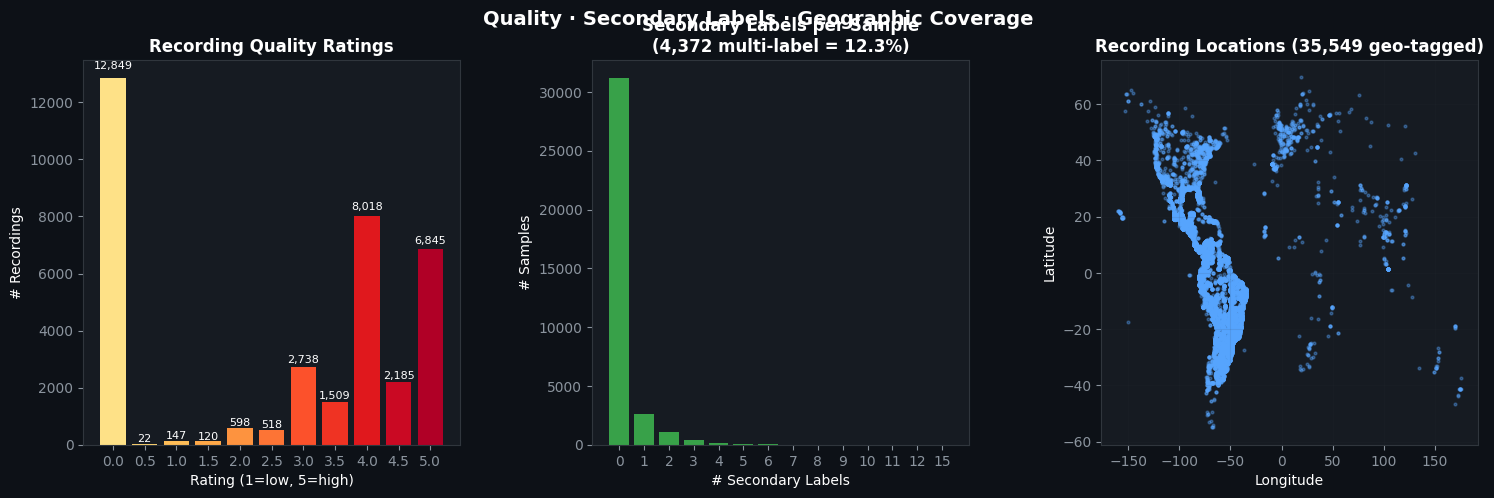

In [16]:
fig = plt.figure(figsize=(18, 5), facecolor=cfg.DARK_BG)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
PANEL_BG = '#161b22'

ax_a = fig.add_subplot(gs[0])
ax_a.set_facecolor(PANEL_BG)
if 'rating' in df.columns:
    rating_counts = df['rating'].value_counts().sort_index()
    bars = ax_a.bar(
        rating_counts.index.astype(str),
        rating_counts.values,
        color=plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(rating_counts))),
        edgecolor='none'
    )
    ax_a.set_title('Recording Quality Ratings', color='white', fontweight='bold')
    ax_a.set_xlabel('Rating (1=low, 5=high)', color='white')
    ax_a.set_ylabel('# Recordings', color='white')
    for bar in bars:
        h = bar.get_height()
        ax_a.text(bar.get_x() + bar.get_width()/2, h + h*0.02,
                  f'{int(h):,}', ha='center', va='bottom',
                  color='white', fontsize=8)
else:
    ax_a.text(0.5, 0.5, 'rating column\nnot found',
              ha='center', va='center', color='#8b949e',
              transform=ax_a.transAxes, fontsize=11)
    ax_a.set_title('Recording Quality', color='white', fontweight='bold')
ax_a.tick_params(colors='#8b949e')
ax_a.spines[:].set_color('#30363d')

ax_b = fig.add_subplot(gs[1])
ax_b.set_facecolor(PANEL_BG)
if 'secondary_labels' in df.columns:
    df['_n_sec'] = df['secondary_labels'].apply(
        lambda x: 0 if (pd.isna(x) or str(x).strip() in ['', '[]'])
                  else len(str(x).split())
    )
    sec_counts = df['_n_sec'].value_counts().sort_index()
    ax_b.bar(sec_counts.index.astype(str), sec_counts.values,
              color='#3fb950', edgecolor='none', alpha=0.85)
    n_multi = (df['_n_sec'] > 0).sum()
    ax_b.set_title(
        f'Secondary Labels per Sample\n({n_multi:,} multi-label = '
        f'{100*n_multi/len(df):.1f}%)',
        color='white', fontweight='bold'
    )
    ax_b.set_xlabel('# Secondary Labels', color='white')
    ax_b.set_ylabel('# Samples', color='white')
else:
    ax_b.text(0.5, 0.5, 'secondary_labels\nnot found',
              ha='center', va='center', color='#8b949e',
              transform=ax_b.transAxes, fontsize=11)
    ax_b.set_title('Secondary Labels', color='white', fontweight='bold')
ax_b.tick_params(colors='#8b949e')
ax_b.spines[:].set_color('#30363d')

ax_c = fig.add_subplot(gs[2])
ax_c.set_facecolor(PANEL_BG)
if 'latitude' in df.columns and 'longitude' in df.columns:
    lat = pd.to_numeric(df['latitude'],  errors='coerce')
    lon = pd.to_numeric(df['longitude'], errors='coerce')
    valid_geo = df[lat.notna() & lon.notna()].copy()
    sc = ax_c.scatter(
        pd.to_numeric(valid_geo['longitude'], errors='coerce'),
        pd.to_numeric(valid_geo['latitude'],  errors='coerce'),
        s=4, alpha=0.35, c=cfg.ACCENT
    )
    ax_c.set_title(
        f'Recording Locations ({len(valid_geo):,} geo-tagged)',
        color='white', fontweight='bold'
    )
    ax_c.set_xlabel('Longitude', color='white')
    ax_c.set_ylabel('Latitude',  color='white')
else:
    ax_c.text(0.5, 0.5, 'lat/lon columns\nnot found',
              ha='center', va='center', color='#8b949e',
              transform=ax_c.transAxes, fontsize=11)
    ax_c.set_title('Recording Locations', color='white', fontweight='bold')
ax_c.tick_params(colors='#8b949e')
ax_c.spines[:].set_color('#30363d')
ax_c.grid(alpha=0.1, color='#30363d')

fig.suptitle('Quality · Secondary Labels · Geographic Coverage',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{cfg.OUTPUT_DIR}/07_quality_geo.png',
            dpi=cfg.FIG_DPI, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 10  Cross-Validation Strategy



In [17]:
skf = StratifiedKFold(n_splits=cfg.N_FOLDS, shuffle=True,
                      random_state=SEED)
df  = df.copy()
df['fold'] = -1

for fold_idx, (_, val_idx) in enumerate(
    skf.split(df, df['primary_label'])
):
    df.loc[df.index[val_idx], 'fold'] = fold_idx

# Per-fold stats
fold_stats = df.groupby('fold').agg(
    n_samples =('primary_label', 'count'),
    n_species =('primary_label', 'nunique'),
).reset_index()
display(fold_stats)


,fold,n_samples,n_species
0,0,7110,198
1,1,7110,198
2,2,7110,199
3,3,7110,199
4,4,7109,198


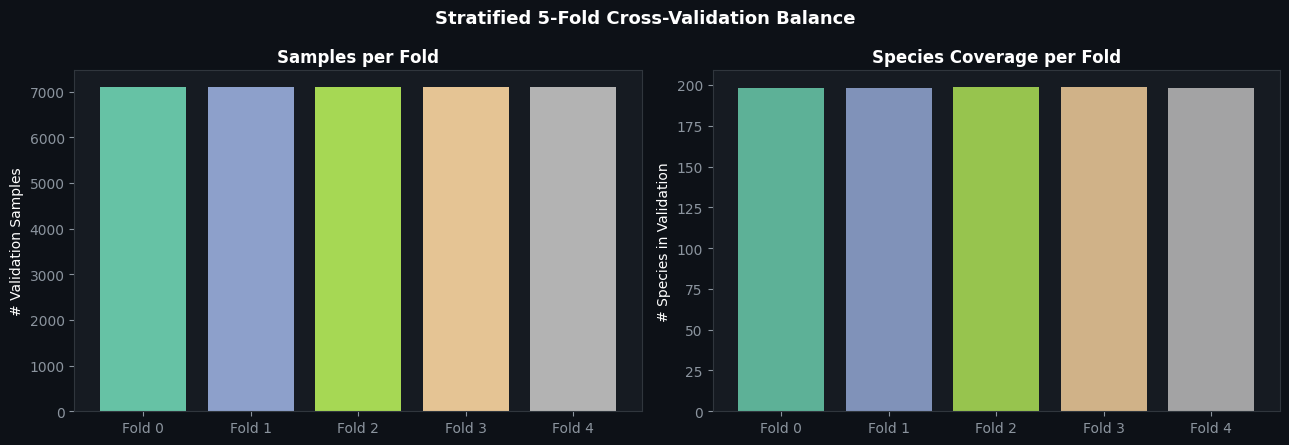

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=cfg.DARK_BG)
PANEL_BG = '#161b22'
fold_colors = plt.cm.Set2(np.linspace(0, 1, cfg.N_FOLDS))

ax = axes[0]
ax.set_facecolor(PANEL_BG)
ax.bar(fold_stats['fold'], fold_stats['n_samples'],
        color=fold_colors, edgecolor='none')
ax.set_xticks(range(cfg.N_FOLDS))
ax.set_xticklabels([f'Fold {i}' for i in range(cfg.N_FOLDS)],
                    color='white')
ax.set_ylabel('# Validation Samples', color='white')
ax.set_title('Samples per Fold', color='white', fontweight='bold')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')

ax2 = axes[1]
ax2.set_facecolor(PANEL_BG)
ax2.bar(fold_stats['fold'], fold_stats['n_species'],
         color=fold_colors, edgecolor='none', alpha=0.9)
ax2.set_xticks(range(cfg.N_FOLDS))
ax2.set_xticklabels([f'Fold {i}' for i in range(cfg.N_FOLDS)],
                     color='white')
ax2.set_ylabel('# Species in Validation', color='white')
ax2.set_title('Species Coverage per Fold', color='white', fontweight='bold')
ax2.tick_params(colors='#8b949e')
ax2.spines[:].set_color('#30363d')

fig.suptitle(f'Stratified {cfg.N_FOLDS}-Fold Cross-Validation Balance',
              color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{cfg.OUTPUT_DIR}/08_cv_folds.png',
            dpi=cfg.FIG_DPI, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

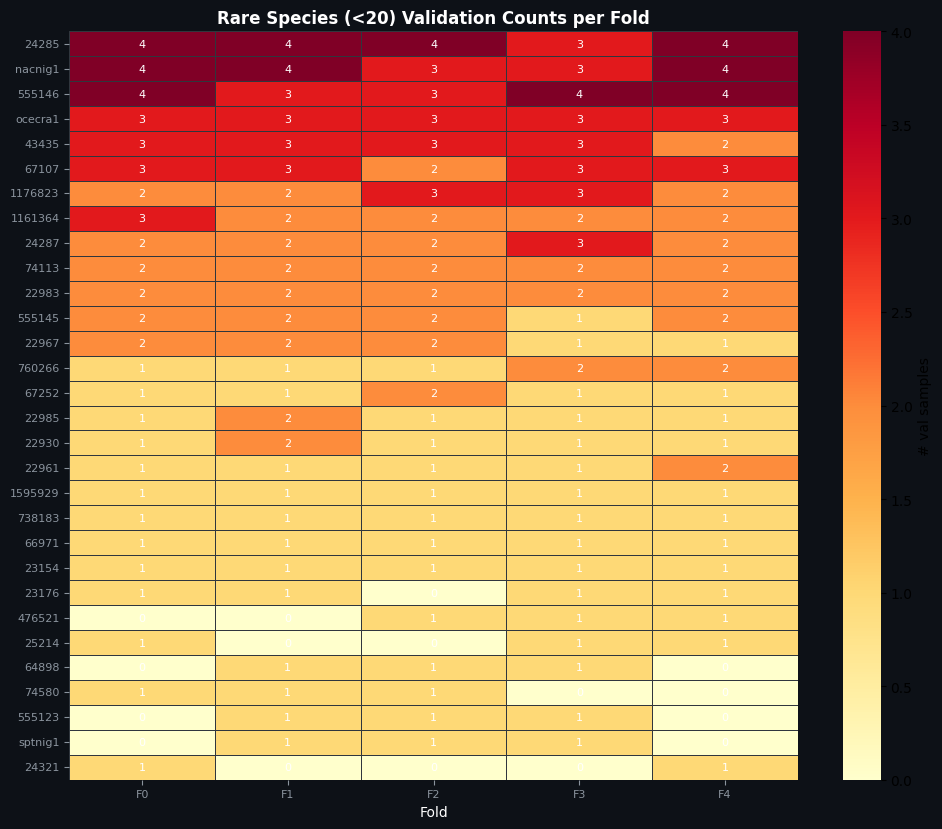

In [19]:
rare_species = counts[counts < cfg.RARE_THRESH].index.tolist()
if rare_species:
    heat_data = np.zeros((len(rare_species), cfg.N_FOLDS), dtype=int)
    rare_df   = df[df['primary_label'].isin(rare_species)]
    for i, sp in enumerate(rare_species):
        for f in range(cfg.N_FOLDS):
            heat_data[i, f] = ((rare_df['primary_label'] == sp)
                               & (rare_df['fold'] == f)).sum()

    n_show = min(30, len(rare_species))
    heat_show = heat_data[:n_show]
    labels_show = rare_species[:n_show]

    fig, ax = plt.subplots(
        figsize=(10, max(4, n_show * 0.28)),
        facecolor=cfg.DARK_BG
    )
    ax.set_facecolor('#161b22')
    sns.heatmap(
        heat_show,
        ax=ax,
        cmap='YlOrRd',
        xticklabels=[f'F{i}' for i in range(cfg.N_FOLDS)],
        yticklabels=labels_show,
        linewidths=0.4,
        linecolor='#30363d',
        annot=True,
        fmt='d',
        annot_kws={'size': 8, 'color': 'white'},
        cbar_kws={'label': '# val samples'},
    )
    ax.set_title(f'Rare Species (<{cfg.RARE_THRESH}) Validation Counts per Fold',
                  color='white', fontweight='bold')
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.set_xlabel('Fold', color='white')
    ax.set_ylabel('')
    plt.tight_layout()
    fig.savefig(f'{cfg.OUTPUT_DIR}/09_rare_species_heatmap.png',
                dpi=cfg.FIG_DPI, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
else:
    print('No rare species found under current threshold.')

## 11  EDA Summary Report


In [20]:
valid_audio = stats_df[stats_df['status'] == 'ok']

summary_data = {
    'Metric': [
        'Total training samples',
        'Unique species',
        'Files confirmed on disk',
        'Corrupted / unreadable files',
        'Mean audio duration (s)',
        'Median audio duration (s)',
        f'Files shorter than {cfg.SEGMENT_SEC}s',
        'Imbalance ratio (max / min samples)',
        f'Rare species (< {cfg.RARE_THRESH} samples)',
        'CV strategy',
        'Primary evaluation metric',
    ],
    'Value': [
        f'{len(df):,}',
        f'{df["primary_label"].nunique()}',
        f'{df["file_exists"].sum():,}',
        f'{(stats_df["status"]=="corrupted").sum()}',
        f'{valid_audio["duration_sec"].mean():.1f}',
        f'{valid_audio["duration_sec"].median():.1f}',
        f'{(valid_audio["duration_sec"] < cfg.SEGMENT_SEC).sum():,}',
        f'{counts.max()/max(counts.min(),1):.1f}x',
        f'{(counts < cfg.RARE_THRESH).sum()}'
        f' ({100*(counts<cfg.RARE_THRESH).mean():.1f}%)',
        f'StratifiedKFold (n={cfg.N_FOLDS}, stratify=primary_label)',
        'ROC-AUC macro (per 5-second window)',
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.style
    .set_properties(**{'text-align': 'left', 'font-size': '13px'})
    .set_table_styles([{
        'selector': 'thead th',
        'props': [('background-color','#161b22'),
                  ('color','#58a6ff'),
                  ('font-weight','bold')]
    }])
    .hide(axis='index')
)

Metric,Value
Total training samples,"35,549"
Unique species,206
Files confirmed on disk,"35,549"
Corrupted / unreadable files,0
Mean audio duration (s),4.9
Median audio duration (s),5.0
Files shorter than 5.0s,212
Imbalance ratio (max / min samples),499.0x
Rare species (< 20 samples),36 (17.5%)
CV strategy,"StratifiedKFold (n=5, stratify=primary_label)"
